In [1]:
!pip install transformers torchvision pandas scikit-learn

In [2]:
# ===== Imports =====

import os
import pandas as pd
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from transformers import BertTokenizer

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# ===== Paths =====

CSV_PATH = "/kaggle/input/datasets/avijitsaha929/bhm-bangla-hate-meme/Dataset_text.csv"
IMAGE_FOLDER = "/kaggle/input/datasets/avijitsaha929/bhm-bangla-hate-meme/Without text/"

In [4]:
# ===== Load CSV =====

df = pd.read_csv(CSV_PATH)

print("Columns:", df.columns)
print(df.head())

Columns: Index(['Image id', 'Caption', 'Label'], dtype='object')
  Image id                                            Caption Label
0    1.jpg  উপদেষ্টার বাবা বলে কথা। উপদেষ্টা আসিফ মাহমুদ স...  fake
1    2.jpg  যেহেতু হাসনাত বলছে তাহলে মনে হয় ভালোর জন্যই বল...  fake
2    3.jpg  শোক সংবাদ। খুবই দুঃখের সাথে জানাচ্ছি যে, বীর ম...  fake
3    4.jpg  হাসিনার স্বীকারোক্তি—কীভাবে আয়নাঘর তৈরি হলো, ক...  fake
4    5.jpg  বিশ্ব মানবতা আজ চরম বিপর্যয়ে! আওয়ামী লীগ করার ...  fake


In [5]:
# ===== Label Encoding =====

df["Label"] = df["Label"].map({
    "real": 0,
    "fake": 1
})

print(df["Label"].value_counts())

Label
0    2280
1    2220
Name: count, dtype: int64


Train / Validation / Test Split

In [6]:
# ===== Dataset Split =====

train_df, temp_df = train_test_split(df, test_size=0.4, random_state=42)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42
)

print("Train:", len(train_df))
print("Valid:", len(valid_df))
print("Test:", len(test_df))

Train: 2700
Valid: 900
Test: 900


Image Transformations

In [7]:
# ===== Image Transform =====

image_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

Tokenizer

In [8]:
# ===== Tokenizer =====

tokenizer = BertTokenizer.from_pretrained("sagorsarker/bangla-bert-base")

vocab.txt: 0.00B [00:00, ?B/s]

Multimodal Dataset Class

In [15]:
# ===== Dataset Class =====

class MultimodalDataset(Dataset):

    def __init__(self, dataframe, image_folder, tokenizer, transforms):
        self.df = dataframe.reset_index(drop=True)
        self.image_folder = image_folder
        self.tokenizer = tokenizer
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        caption = str(row["Caption"])
        label = int(row["Label"])
        image_name = row["Image id"]

        image_path = os.path.join(self.image_folder, image_name)

        image = Image.open(image_path).convert("RGB")
        image = self.transforms(image)

        text = self.tokenizer(
            caption,
            padding="max_length",
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        return {
            "input_ids": text["input_ids"].squeeze(),
            "attention_mask": text["attention_mask"].squeeze(),
            "pixel_values": image,
            "label": torch.tensor(label)
        }

Create Datasets

In [16]:
# ===== Dataset Objects =====

train_dataset = MultimodalDataset(train_df, IMAGE_FOLDER, tokenizer, image_transforms)
valid_dataset = MultimodalDataset(valid_df, IMAGE_FOLDER, tokenizer, image_transforms)
test_dataset  = MultimodalDataset(test_df, IMAGE_FOLDER, tokenizer, image_transforms)

DataLoaders

In [17]:
# ===== DataLoaders =====

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

Model Definition

In [18]:
# ===== Model =====

class MultimodalClassifier(nn.Module):

    def __init__(self, vocab_size, embed_dim=512, num_classes=2):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.text_encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=embed_dim,
                nhead=8
            ),
            num_layers=4
        )

        self.image_encoder = nn.Sequential(

            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(32*56*56,512),
            nn.ReLU()
        )

        self.classifier = nn.Linear(embed_dim + 512, num_classes)

    def forward(self, input_ids, attention_mask, images):

        text_embed = self.embedding(input_ids)

        text_features = self.text_encoder(text_embed.transpose(0,1))
        text_features = text_features.transpose(0,1)[:,0,:]

        image_features = self.image_encoder(images)

        combined = torch.cat((text_features, image_features), dim=1)

        logits = self.classifier(combined)

        return logits

Initialize Model

In [19]:
# ===== Model Setup =====

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultimodalClassifier(
    vocab_size=tokenizer.vocab_size
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=2e-4)

Training Loop

In [20]:
# ===== Training =====

num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch in train_loader:

        input_ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        images = batch["pixel_values"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids, mask, images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs,1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    train_acc = correct / total

    print(f"Epoch {epoch+1} | Loss {total_loss/len(train_loader):.4f} | Acc {train_acc:.4f}")

Epoch 1 | Loss 0.2880 | Acc 0.9263
Epoch 2 | Loss 0.0163 | Acc 0.9959
Epoch 3 | Loss 0.0068 | Acc 0.9989
Epoch 4 | Loss 0.0036 | Acc 0.9993
Epoch 5 | Loss 0.0010 | Acc 1.0000


Validation

In [21]:
# ===== Validation =====

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for batch in valid_loader:

        input_ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        images = batch["pixel_values"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids, mask, images)

        preds = torch.argmax(outputs,1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Validation Accuracy:", accuracy_score(all_labels, all_preds))

Validation Accuracy: 0.9988888888888889


Test Evaluation

In [22]:
# ===== Test Evaluation =====

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        images = batch["pixel_values"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids, mask, images)

        preds = torch.argmax(outputs,1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       500
           1       1.00      1.00      1.00       400

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



Save Model

In [23]:
# ===== Save Model =====

torch.save(model.state_dict(), "/kaggle/working/multimodal_model.pth")

Confusion Matrix

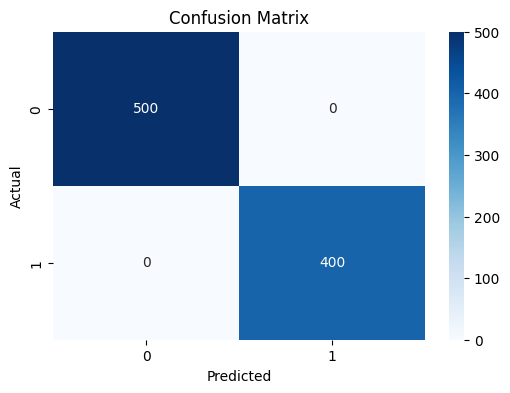

In [24]:
# ===== Confusion Matrix =====

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()